# France: skills and salary regression

Pilot analysis for French technology vacancies. The notebook tests whether the skills reported in each advert contain useful salary information. It uses a leakage-safe train/test split and compares a median baseline with Ridge regression.

> Important: `fr_final.csv` is already a selected sample of technology-related adverts and has previously been salary-filtered. Results describe this sample, not the entire French labour market.

In [1]:
from pathlib import Path
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42

# Locate the project data even if Jupyter starts in a parent directory.
search_roots = [Path.cwd(), *Path.cwd().parents]
DATA_PATH = next(
    (root / 'files/cleaned/fr_final.csv' for root in search_roots
     if (root / 'files/cleaned/fr_final.csv').exists()),
    None,
)
if DATA_PATH is None:
    raise FileNotFoundError(
        'Could not find files/cleaned/fr_final.csv. Open the notebook inside the project folder.'
    )
print(f'Using data: {DATA_PATH}')

Using data: /Users/ioannabousmpouki/Desktop/reposkills/green-ai-skills/green-ai-skills/files/cleaned/fr_final.csv


## 1. Load and audit the sample

In [2]:
df = pd.read_csv(DATA_PATH, sep=';', low_memory=False)
print(f'Rows: {len(df):,}')
print(f'Unique adverts: {df.documentId.nunique():,}')
display(df[['annual_salary', 'salary.currency', 'salary.period']].describe(include='all'))

Rows: 1,019
Unique adverts: 1,002


,annual_salary,salary.currency,salary.period
count,1019.000000,1019,1019
unique,NaN,1,2
top,NaN,EUR,year
freq,NaN,1019,949
mean,45634.430010,NaN,NaN
std,11661.112208,NaN,NaN
min,21850.000000,NaN,NaN
25%,37500.000000,NaN,NaN
50%,45000.000000,NaN,NaN
75%,52500.000000,NaN,NaN


In [3]:
def parse_list_cell(value):
    if isinstance(value, list):
        return [str(item).strip() for item in value if str(item).strip()]
    if pd.isna(value):
        return []
    try:
        parsed = ast.literal_eval(str(value))
        return [str(item).strip() for item in parsed] if isinstance(parsed, list) else []
    except (ValueError, SyntaxError):
        return []

df['skills'] = df['skills_list_clean'].apply(parse_list_cell)
df['annual_salary'] = pd.to_numeric(df['annual_salary'], errors='coerce')
analysis_df = df.loc[
    df['annual_salary'].gt(0) & df['skills'].map(bool)
].drop_duplicates('documentId').copy()

print(f'Usable rows: {len(analysis_df):,}')
print(f'Median salary: €{analysis_df.annual_salary.median():,.0f}')
print(f'Median skills per advert: {analysis_df.skills.map(len).median():.0f}')

Usable rows: 1,002
Median salary: €45,000
Median skills per advert: 1


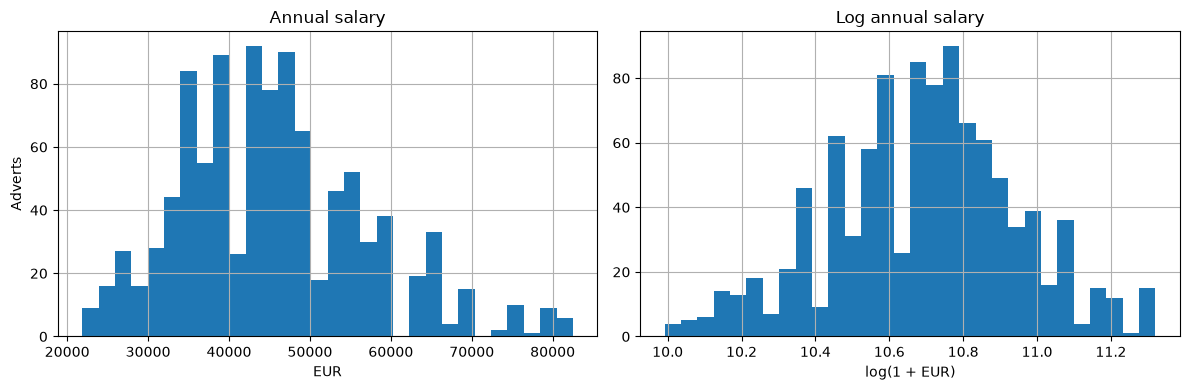

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
analysis_df['annual_salary'].hist(bins=30, ax=axes[0])
axes[0].set(title='Annual salary', xlabel='EUR', ylabel='Adverts')
np.log1p(analysis_df['annual_salary']).hist(bins=30, ax=axes[1])
axes[1].set(title='Log annual salary', xlabel='log(1 + EUR)')
plt.tight_layout();

## 2. Skill frequencies

Rare skills are excluded from the model to reduce unstable coefficients. The vocabulary is learned on the training set only.

In [5]:
skill_counts = analysis_df['skills'].explode().value_counts()
display(skill_counts.head(25).rename('advert_count').to_frame())

,advert_count
skills,
DevOps,155
cyber security,145
Python (computer programming),137
SQL,111
PostgreSQL,97
Java (computer programming),94
Jenkins (tools for software configuration management),72
SQL Server,60
TypeScript,59


## 3. Train/test split and baseline

In [6]:
# CountVectorizer expects one document per row. The separator prevents
# multi-word ESCO labels from being split into individual words.
X = analysis_df['skills'].map(lambda values: ' || '.join(values))
y = analysis_df['annual_salary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

def evaluate(name, estimator):
    estimator.fit(X_train, y_train)
    prediction = estimator.predict(X_test)
    return {
        'model': name,
        'MAE_EUR': mean_absolute_error(y_test, prediction),
        'RMSE_EUR': mean_squared_error(y_test, prediction) ** 0.5,
        'R2': r2_score(y_test, prediction),
    }, estimator, prediction

baseline = DummyRegressor(strategy='median')
baseline_result, baseline, baseline_prediction = evaluate('Median baseline', baseline)

## 4. Ridge regression on skills

The target is fitted on the logarithmic scale because salaries are right-skewed. Ridge regularisation is appropriate for many correlated binary skill indicators.

In [7]:
skill_encoder = CountVectorizer(
    tokenizer=lambda text: text.split(' || '),
    token_pattern=None,
    lowercase=True,
    binary=True,
    min_df=5
)
ridge_pipeline = Pipeline([
    ('skills', skill_encoder),
    ('ridge', Ridge(alpha=10.0))
])
ridge_model = TransformedTargetRegressor(
    regressor=ridge_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)
ridge_result, ridge_model, ridge_prediction = evaluate('Skills Ridge', ridge_model)
results = pd.DataFrame([baseline_result, ridge_result]).set_index('model')
display(results.round({'MAE_EUR': 0, 'RMSE_EUR': 0, 'R2': 3}))

,MAE_EUR,RMSE_EUR,R2
model,,,
Median baseline,9156.0,12020.0,-0.015
Skills Ridge,8493.0,11421.0,0.084


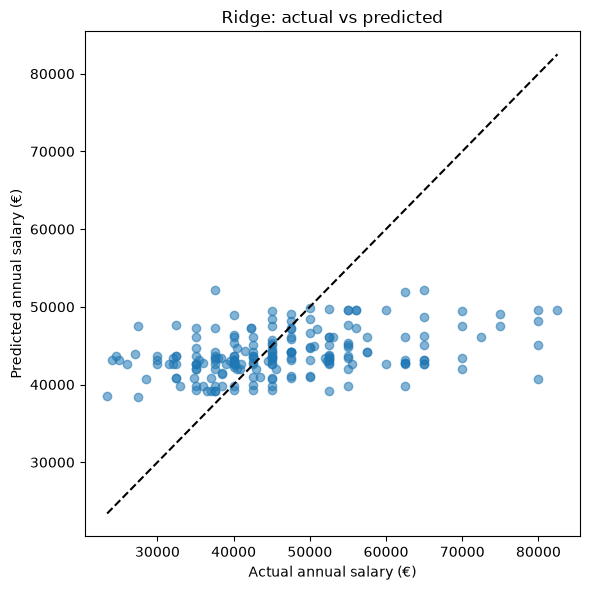

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, ridge_prediction, alpha=0.55)
low = min(y_test.min(), ridge_prediction.min())
high = max(y_test.max(), ridge_prediction.max())
ax.plot([low, high], [low, high], '--', color='black')
ax.set(xlabel='Actual annual salary (€)', ylabel='Predicted annual salary (€)', title='Ridge: actual vs predicted')
plt.tight_layout();

## 5. Inspect skill coefficients

Coefficients are associations conditional on the other encoded skills. They are not causal skill premiums.

In [9]:
fitted_pipeline = ridge_model.regressor_
feature_names = fitted_pipeline.named_steps['skills'].get_feature_names_out()
coefficients = fitted_pipeline.named_steps['ridge'].coef_
coef_df = pd.DataFrame({'skill': feature_names, 'log_salary_coefficient': coefficients})
coef_df['approx_percent_association'] = 100 * np.expm1(coef_df['log_salary_coefficient'])

print('Largest positive associations')
display(coef_df.nlargest(15, 'log_salary_coefficient'))
print('Largest negative associations')
display(coef_df.nsmallest(15, 'log_salary_coefficient'))

Largest positive associations


,skill,log_salary_coefficient,approx_percent_association
30,typescript,0.121039,12.866837
5,data engineering,0.117096,12.422758
10,devops,0.093361,9.785749
16,jenkins (tools for software configuration mana...,0.070765,7.332923
25,software architecture models,0.068408,7.080219
15,javascript framework,0.064309,6.642238
12,handle cybersecurity incidents,0.058758,6.051816
21,postgresql,0.049011,5.023153
18,natural language processing,0.046380,4.747217
19,nosql,0.040970,4.182136


Largest negative associations


,skill,log_salary_coefficient,approx_percent_association
11,ensure information security,-0.186450,-17.009956
31,use methods of logistical data analysis,-0.092791,-8.861637
1,building automation,-0.087437,-8.372369
8,design automation components,-0.071365,-6.887769
32,web analytics,-0.067733,-6.549049
27,sql server,-0.056221,-5.467026
20,php,-0.055051,-5.356302
23,rapid application development,-0.048401,-4.724848
14,javascript,-0.040325,-3.952237
9,develop information security strategy,-0.031899,-3.139532


## Interpretation checklist

1. Ridge should beat the median baseline on MAE and have positive test R² before interpreting coefficients.
2. A negative test R² means skills alone do not generalise well enough with the current sample.
3. Skill coefficients are associations, not causal effects. Seniority, location, occupation, education and contract type are possible confounders.
4. The next iteration should rebuild the French sample from the extracted file with an explicit relevance score, then add occupation and seniority features.
5. Do not delete high salaries solely with a global z-score; inspect them against period, currency and occupation first.